# Imports

In [1]:
#%matplotlib notebook
#para que funcione voila
%matplotlib ipympl
import os
from datetime import datetime
from IPython.display import display, HTML
import ipywidgets as widgets


from pathlib import Path  #to get user directory
from IPython.display import clear_output
#importa las fuciones que cree desde otro notebook (instalar modulo ipynb)
#import ipynb.fs.full.my_funcs_clusters as myfunc
import my_funcs_clusters as myfunc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
import matplotlib.dates as mdates #para poner meses en las ticks
from matplotlib import image
import classPlotSubClusterInt
import matplotlib
#matplotlib.use('nbAgg')
#valores despues del punto decimal
pd.set_option("display.precision", 4)

In [2]:
import importlib
importlib.reload(myfunc);

# Data processing

In [4]:
data_path ='datos/DP-PB01-2005.xlsx'

mf_pow_curve_path ='datos/DeWind d8.2.csv'
df_wind_dir, df_comp_vel,df_mf_curve = myfunc.proc_dat_bcs(data_path,mf_pow_curve_path)

Inciando procesamiento de datos...
Total de registros: 52560
Numero de filas sin datos
day      0.0
hour     0.0
wdir     0.0
vwind    0.0
dtype: float64
Fin del procesamiento de datos


# Time series
La gráfica que muestra las variaciones de velocidad de viento a lo largo del tiempo es llamada serie de tiempo. La
serie de tiempo que corresponde a los datos registrados en el año 2005 en baja california se muestran en la Figura 1.

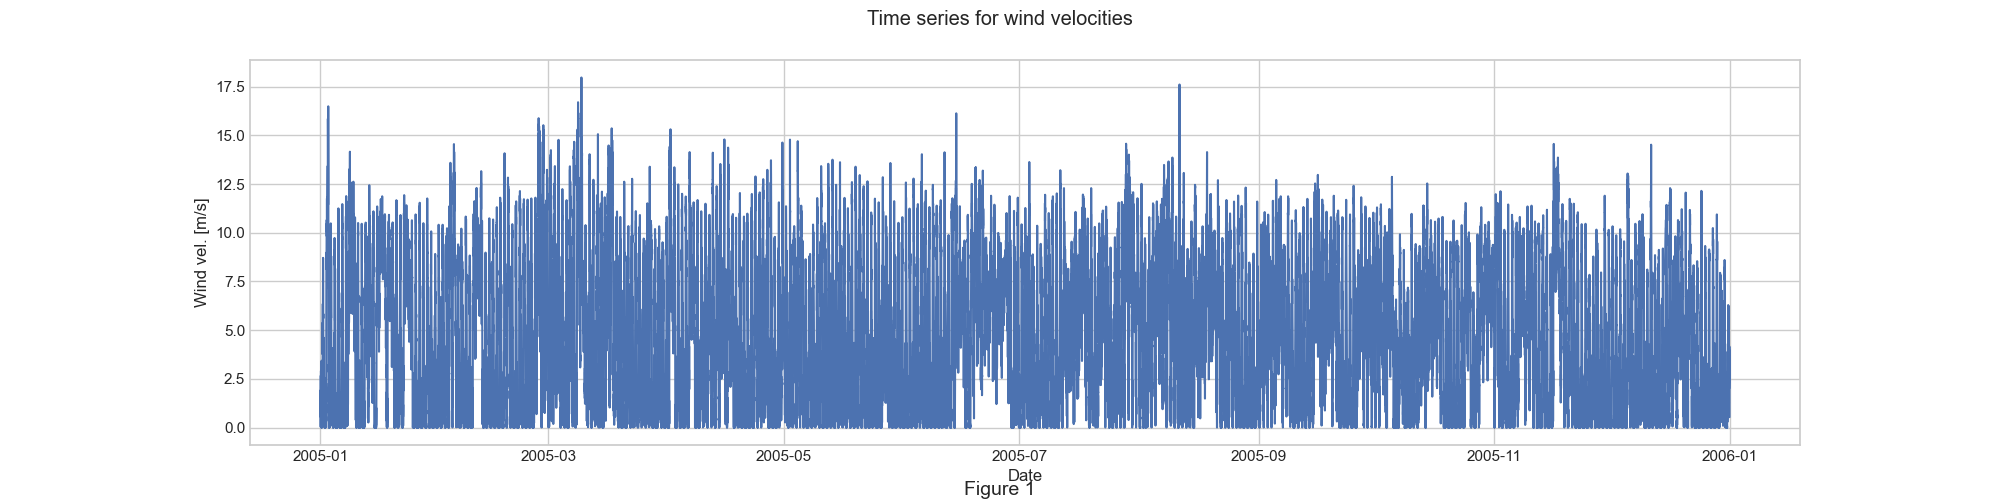

In [4]:
plt.figure(1,figsize=(20,5))
plt.suptitle('Time series for wind velocities')
plt.plot(df_wind_dir.index, df_wind_dir.vwind)
plt.figtext(0.5, 0.01, 'Figure '+ str(plt.gcf().number), wrap=True, horizontalalignment='center', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Wind vel. [m/s]')
plt.show()

# Velocity components
Los vectores de velocidad de viento se pueden descomponer en sus componentes horizontales y verticales. Si gráficamos
estos componentes, obtenemos un gráfico similar al llamado espacio de fases en mecánica estadística. El espacio de
fases contiene todos los posibles estados y las regiones donde los ponemos encontrar. Fuera de estas regiones no
puede existir ningún estado. En este mismo sentido, podemos definir un "estado de viento" como una región dentro del
espacio de estados que comparte características de velocidad de viento y dirección similares.

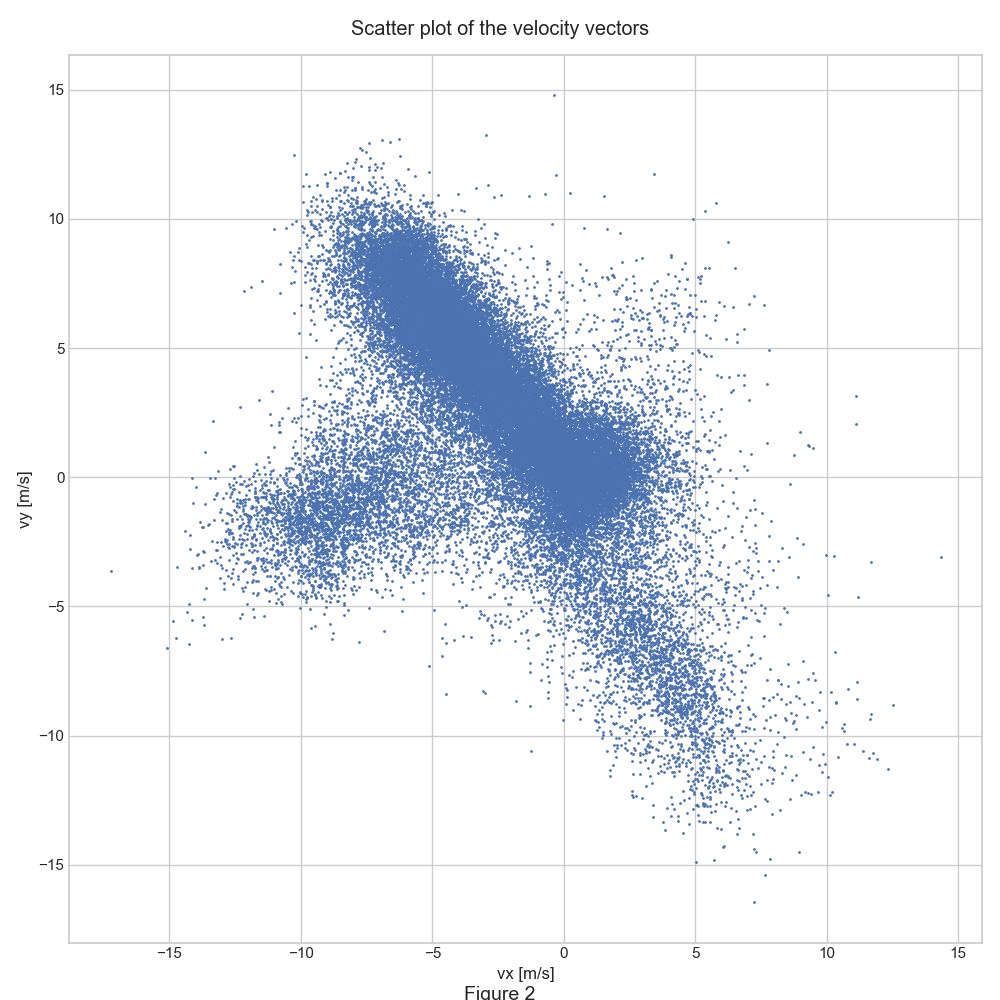

In [5]:
plt.figure(2,figsize=(10,10))
plt.suptitle('Scatter plot of the velocity vectors')
plt.scatter(df_comp_vel.vx,df_comp_vel.vy,s=1)
plt.xlabel('vx [m/s]')
plt.ylabel('vy [m/s]')
plt.tight_layout()
plt.figtext(0.5, 0.0, 'Figure '+ str(plt.gcf().number), wrap=True, horizontalalignment='center', fontsize=14)
plt.show()

# Histogram and density plot
Una forma de encontrar los estados en el espacio de fases, es observando el plot de densidades y el histograma de
frecuencia de los componentes de velocidad. En la Figure 3 podemos observar 5 regiones en el espacio de fases que
podemos clasificar como estados de viento.

C:\Users\mungu\AppData\Local\Temp\ipykernel_32800\2659966226.py:127: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


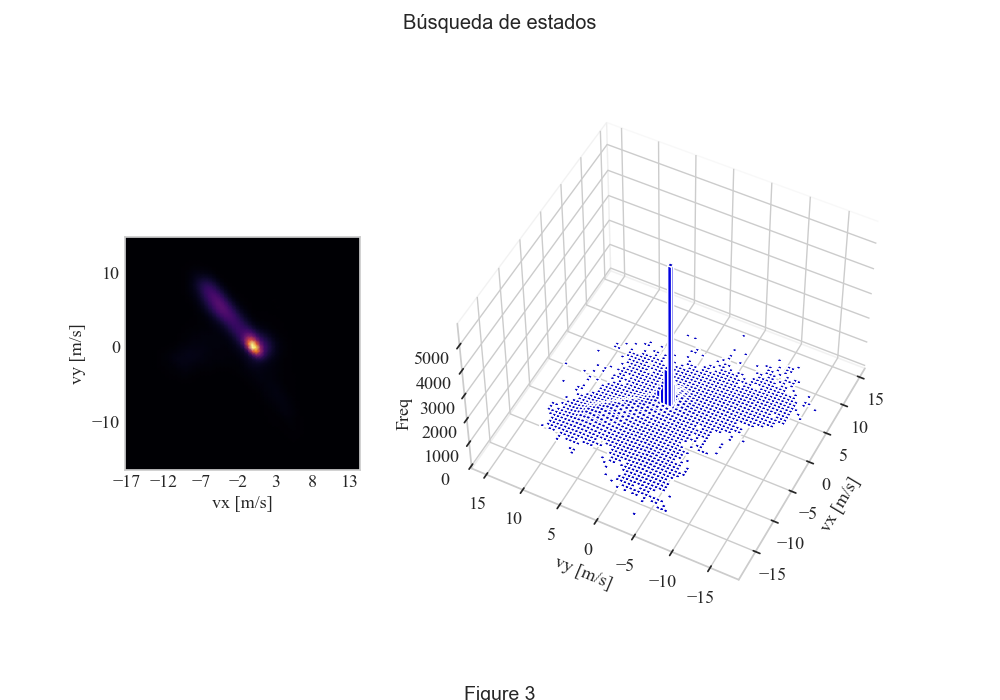

In [6]:
fontsize = 13
labelFontSize = 13
tickFontSize = 12
markerSize = 100
fontNameLabel = {'fontname':'Times New Roman'}
fontNameCluster = {'fontname':'Arial'}
ticks_font = font_manager.FontProperties(family='Times New Roman', style='normal',
                                         size=labelFontSize, weight='normal', stretch='normal')
ticks_font = font_manager.FontProperties(family='Times New Roman', style='normal',
                                         size=labelFontSize, weight='normal', stretch='normal')
#en esta celda se usa gridspec para cambiar el tamaño de subplots individuales
from scipy.stats import gaussian_kde

pltfstitle =10 #tamaño de fuente
pltfslbl =13
nbins =60

H, xedges, yedges = np.histogram2d(df_comp_vel.vx.values, df_comp_vel.vy.values,bins=nbins )
H=H.T;
#
# Create an X-Y mesh of the same dimension as the 2D data. You can
# think of this as the floor of the plot.
#

x_data, y_data = np.meshgrid( xedges[:-1],yedges[:-1])
# Flatten out the arrays so that they may be passed to "ax.bar3d".
# Basically, ax.bar3d expects three one-dimensional arrays:
# x_data, y_data, z_data. The following call boils down to picking
# one entry from each array and plotting a bar to from
# (x_data[i], y_data[i], 0) to (x_data[i], y_data[i], z_data[i]).
#
x_data = x_data.flatten()
y_data = y_data.flatten()
z_data = H.flatten()

# Create a figure for plotting the data as a 3D histogram.
#
fig = plt.figure(figsize=(10,7))

# eliminar elementos con frecuencia zero
a = z_data[z_data != 0]
idx=np.where(z_data == 0)[0]
b=np.delete(x_data,idx)
c=np.delete(y_data,idx)
z_data=a
x_data=b
y_data=c

# tres graficas
#cmap del histograma2d. Es un array de nx 4 elementos (rgba)
#histograma 3d
#ax = fig.add_subplot(121, projection='3d')
#grid = plt.GridSpec(2,2, wspace=0.3, hspace=0.1)
#axScatter=fig.add_subplot(grid[0, 0])
#axDensity= fig.add_subplot(grid[0, 1])
#axHist2d =fig.add_subplot(grid[1,0: ], projection='3d')

# dos graficas
#cmap del histograma2d. Es un array de nx 4 elementos (rgba)
#histograma 3d
#ax = fig.add_subplot(121, projection='3d')
grid = plt.GridSpec(1, 2, width_ratios=[1, 2])

#grid = plt.GridSpec(1,2, wspace=0.3, hspace=0.1)
#axScatter=fig.add_subplot(grid[0, 0])
axDensity= fig.add_subplot(grid[0, 0])
axHist2d =fig.add_subplot(grid[0,1 ], projection='3d')

#SCATTER
#axScatter.scatter(df_comp_vel.vx,df_comp_vel.vy,s=0.6)
#axScatter.set_ylabel('vy [m/s]', fontsize = pltfslbl)
#axScatter.set_xlabel('vx [m/s]', fontsize = pltfslbl)
##axScatter.set_aspect('equal')
#axScatter.set_xticks(np.arange(np.around(df_comp_vel.vx.min()),df_comp_vel.vx.max(),5))

#DENSITY PLOT

data = np.array(df_comp_vel.values.tolist())
x, y = data.T
# Evaluate a gaussian kde on a regular grid of nbins x nbins over data extents
k = gaussian_kde(data.T)
xi, yi = np.mgrid[x.min():x.max():nbins*1j, y.min():y.max():nbins*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

axDensity.set_ylabel('vy [m/s]', fontsize = pltfslbl,fontname='Times New Roman')
axDensity.set_xlabel('vx [m/s]', fontsize = pltfslbl,fontname='Times New Roman')
axDensity.tick_params(axis='both', labelsize = pltfslbl)
axDensity.set_aspect('equal')
axDensity.set_xticks(np.arange(np.around(df_comp_vel.vx.min()),df_comp_vel.vx.max(),5))


#guardo el objeto pcolormesh para obtener su cmap
axDensity.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='gouraud', cmap=plt.cm.inferno)

#HIST2D
axHist2d.tick_params(axis='both', labelsize = pltfslbl)
ancho_barra =0.5
largo_barra = 0.5
axHist2d.bar3d( x_data,
                y_data,
                np.zeros_like(z_data),
                ancho_barra, largo_barra, z_data, shade=True,
                color = 'blue')
axHist2d.xaxis.pane.fill = False
axHist2d.yaxis.pane.fill = False
axHist2d.zaxis.pane.fill = False
axHist2d.set_aspect('auto')

#Vista del histograma 3d
axHist2d.view_init(50,-153)
axHist2d.set_ylabel('vy [m/s]', fontsize = pltfslbl,fontname='Times New Roman')
axHist2d.set_xlabel('vx [m/s]', fontsize = pltfslbl,fontname='Times New Roman')
axHist2d.set_zlabel('Freq', fontsize = pltfslbl, rotation= 90,fontname='Times New Roman')

for label in axDensity.get_xticklabels():
    label.set_fontproperties(ticks_font)
for label in axDensity.get_yticklabels():
    label.set_fontproperties(ticks_font)

for label in axHist2d.get_xticklabels():
    label.set_fontproperties(ticks_font)
for label in axHist2d.get_yticklabels():
    label.set_fontproperties(ticks_font)
for label in axHist2d.get_zticklabels():
    label.set_fontproperties(ticks_font)

plt.tight_layout()

#figsavetime = datetime.datetime.now().strftime("%d-%m-%Y_%H_%M_%S_%f")
#plt.savefig('fig_art/pdf_hist2d_'+ figsavetime +'.png', bbox_inches='tight', pad_inches=0.1)

plt.suptitle('Búsqueda de estados')
plt.figtext(0.5, 0.0, 'Figure '+ str(plt.gcf().number), wrap=True, horizontalalignment='center', fontsize=14)

plt.show()

# Clusters
Ya que tenemos identificados los estados, los encontramos usando un método de agrupamiento llamado k-means. EL método
k-means encuentra puntos en los datos que funcionaran como ancla para definir que puntos se encuentran dentro de
determinado grupo mediante distancias euclidianas y el algoritmo de <i> maximum-likelihood</i>. Se eligieron
empíricamente 15 grupos, los cuales corresponden a 15 estados dentro del espacio de fases. La gráfica con los 15
estados de viento dentro del espacio de fases se muestra en la Figure 4.

In [7]:
n_clusters = 15
clusters_wind = myfunc.KMData()
clusters_wind.dataframe_to_cluster(df_comp_vel, n_clusters=n_clusters, clusters_data='wind')
#crear un dataframe viento, direccion, cluster
df_wind_dir_cl = df_wind_dir.copy()
#tomando las labels de kmeans y sumandole uno por que empieza en 0
#ademas agregando la letra C y ordenando de menor v a mayor vel
col_clnames = ['C' + str(clusters_wind.cl_ord[c]+1) for c in clusters_wind.kmeans_labels]
df_wind_dir_cl['cluster'] = col_clnames
del col_clnames

   Kmeans devuelve una lista de etiquetas, donde cada etiqueta es un número que corresponde a un cluster determinado. La
ubicacion de los
centroides se muestra a continuación:


In [8]:
clusters_wind.idx_centroids


,cluster_ID,PCTimeStamp,vx,vy,mag_windv
cluster_ID_ord,,,,,
1,13,2005-05-21 03:40:00,0.0147,0.1009,0.102
2,5,2005-03-25 06:50:00,-0.9554,1.7968,2.035
3,11,2005-07-09 10:00:00,1.9850,0.4437,2.034
4,0,2005-03-30 01:30:00,0.1821,-2.6718,2.678
5,4,2005-09-17 20:10:00,-2.7005,3.5016,4.422
6,9,2005-09-11 11:30:00,-4.5031,-1.0894,4.633
7,8,2005-04-11 13:00:00,4.4316,-2.6000,5.138
8,6,2005-12-24 13:40:00,2.9314,5.1812,5.953
9,10,2005-10-17 08:00:00,-4.1832,5.1218,6.613


En la tabla se muestra la diferencia entre la magnitud de la velocidad de viento de un cluster y el siguente (columna
difer).

In [9]:
df_diff_windv = clusters_wind.idx_centroids.copy()
for i in range(4):
    df_diff_windv.drop(df_diff_windv.columns[0],inplace=True,axis=1)
df_diff_windv['difer'] = df_diff_windv.diff().values
text_dif_prom ="La distancia promedio es %0.2f m/s"%df_diff_windv.difer.mean()
#este es para voila, que se vea el dataframe bonito
display(HTML(df_diff_windv.to_html()))
display(HTML('<p style="e;font-size:16px;">' +text_dif_prom))

,mag_windv,difer
cluster_ID_ord,,
1,0.102,NaN
2,2.035,1.933
3,2.034,-0.001
4,2.678,0.644
5,4.422,1.744
6,4.633,0.211
7,5.138,0.505
8,5.953,0.815
9,6.613,0.660


# Plot clusters

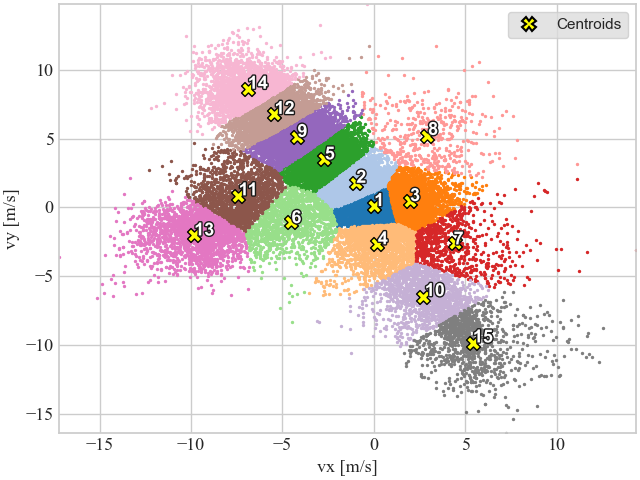

In [10]:
clsclord=('wind',None)
ploti = classPlotSubClusterInt.PlotSubClusterInt()
ploti.create_plot(
    clusters_wind.comp_vel,
    figsize=(20, 10),
    idx_centroids=clusters_wind.idx_centroids,
    fign='Figure '+ str(plt.gcf().number+1),
    save_folder='figures_tests/',
    filename = 'plot_clusters_joined',
    showlBetz=False,
    showCent= True,
    showOpt= 'Numero',
    dfMfgCurve=df_mf_curve
)

# Grouping clusters
Se pueden agrupar los clusters en clusters que no produzcan energía, y clusters que produzcan energía. Si suponemos
que la velocidad de cut-in del aerogenerador es de 4 m/s, podemos decir que las velocidades iguales a menores a la
velocidad de cut-in producen 0 Mw y se pueden agrupar en un solo cluster. La probabilidad de ocurrencia de cada
estado se muestra en el siguiente tabla:

In [11]:
#probabilidades de cada estado
dfclvv = myfunc.create_clustered_data(df_wind_dir,clusters_wind.kmeans_labels)

nregcl=[]
for col in dfclvv.columns:
    nregcl.append(len(dfclvv[dfclvv[col].notna()]))
ntotreg= len(df_wind_dir)
df_prob_x_estado = pd.DataFrame(clusters_wind.idx_centroids['mag_windv'].values,columns=['vel'])
df_prob_x_estado.set_index(dfclvv.columns,inplace=True)
df_prob_x_estado.index.name= 'cluster'
df_prob_x_estado['%prob']=np.array(nregcl)/ntotreg *100
df_prob_x_estado

,vel,%prob
cluster,,
C1,0.102,24.2546
C2,2.035,9.6748
C3,2.034,7.0587
C4,2.678,3.8756
C5,4.422,9.8156
C6,4.633,2.6066
C7,5.138,1.3851
C8,5.953,0.8771
C9,6.613,11.5356


 Además, si agrupamos los clusters conjuntos con velocidades de viento similares y porcentajes de ocurrencia
significativos, podemos agrupar los clusters de la siguiente manera:
<ul>
<li>C1, C2, C3, C4, C5 y C6</li>
<li>C8 y C9 </li>
<li>C10 y C11</li>
<li>C12 y C13</li>
<li>C14 y C15</li>
</ul>

El cluster C7 se elimina debido a la baja probabilidad de ocurrir.


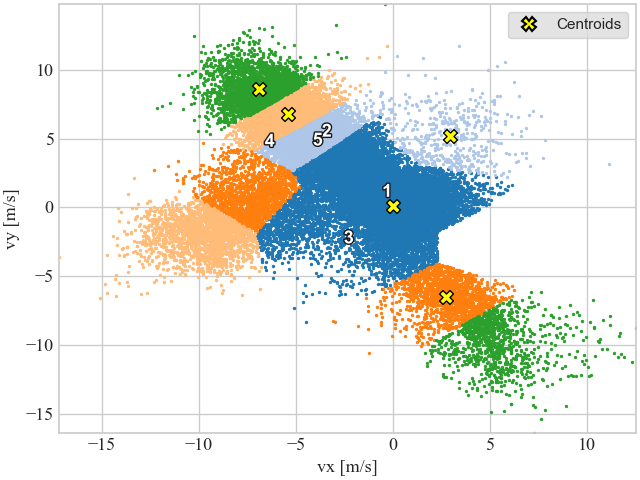

In [12]:
col_to_join = [['C1','C2','C3','C4','C5','C6',],['C8','C9'],['C10','C11'],['C12','C13'],['C14','C15']]
col_to_del = [['C7']]
dfclvv_joined = myfunc.join_clusters(dfclvv.copy(),col_to_join,col_to_del)
df_comp_vel_joined = myfunc.join_clusters(clusters_wind.comp_vel.copy(),col_to_join,col_to_del)
clsclord=('wind',None)
ploti2 = classPlotSubClusterInt.PlotSubClusterInt()
ploti2.create_plot(
    df_comp_vel_joined,
    figsize=(20, 10),
    idx_centroids=clusters_wind.idx_centroids,
    fign='Figure '+ str(plt.gcf().number+1),
    save_folder='figures_tests/',
    filename = 'plot_clusters_joined2',
    showlBetz=False,
    showCent= True,
    showOpt= 'Numero',
    dfMfgCurve=df_mf_curve)


  Si hacemos una operación de clustering cambiando el número de clusters de 15 a 5 se obtiene la imagen.


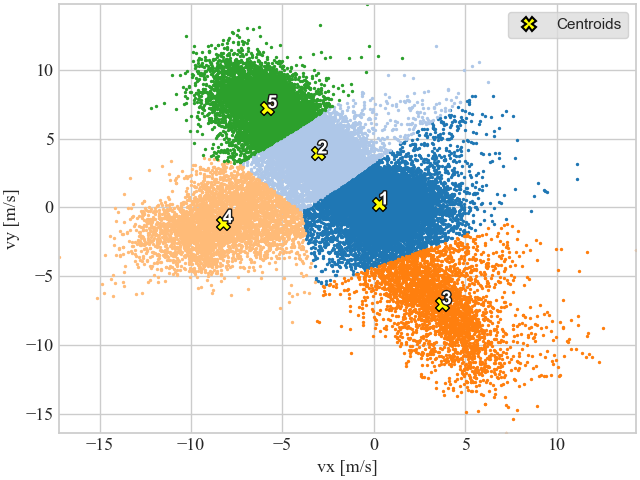

In [13]:
n_clusters = 5
clusters_wind_5 = myfunc.KMData()
clusters_wind_5.dataframe_to_cluster(df_comp_vel, n_clusters=n_clusters, clusters_data='wind')
clsclord=('wind',None)

ploti3 = classPlotSubClusterInt.PlotSubClusterInt()
ploti3.create_plot(
    clusters_wind_5.comp_vel,
    figsize=(20, 10),
    idx_centroids=clusters_wind_5.idx_centroids,
    fign='Figure '+ str(plt.gcf().number+1),
    save_folder='figures_tests/',
    filename = 'plot_clusters_joined2',
    showlBetz=False,
    showCent= True,
    showOpt= 'Numero',
    dfMfgCurve=df_mf_curve)


En las dos figuras anteriores se comparan los clusters automáticos vs los manuales. La siguiente tabla muestra de manera cuantitiva la diferencia entre las magnitudes de viento de los clusters calculados manualmente vs los clusters calculados automaticamente.

In [14]:
#comparacion de magnitudes de vv de clusters automaticos vs manuales
prom = []
for c in dfclvv_joined.columns:
    prom.append(dfclvv_joined[c].mean())
df_comp_clust = clusters_wind_5.idx_centroids.copy()
df_comp_clust.reset_index(inplace=True)
cols_to_del =['cluster_ID','vx','vy']
for i in cols_to_del:
    df_comp_clust.drop(i,axis=1,inplace=True )
df_comp_clust.set_index('PCTimeStamp',inplace=True)
df_comp_clust.columns=['cl_auto','mag_auto']
df_comp_clust.cl_auto=df_comp_clust.cl_auto.apply(lambda c:'C'+str(c))
df_comp_clust['cl_manual'] = dfclvv_joined.columns
df_comp_clust['mag_manual'] = prom
df_comp_clust

,cl_auto,mag_auto,cl_manual,mag_manual
PCTimeStamp,,,,
2005-01-02 11:10:00,C1,0.347,C1,2.0368
2005-06-17 11:20:00,C2,4.985,C8,6.6672
2005-03-13 19:00:00,C3,7.980,C10,7.3575
2005-08-15 09:20:00,C4,8.320,C12,9.1249
2005-10-30 15:50:00,C5,9.290,C14,11.1505


# Curva de potencia del fabricante

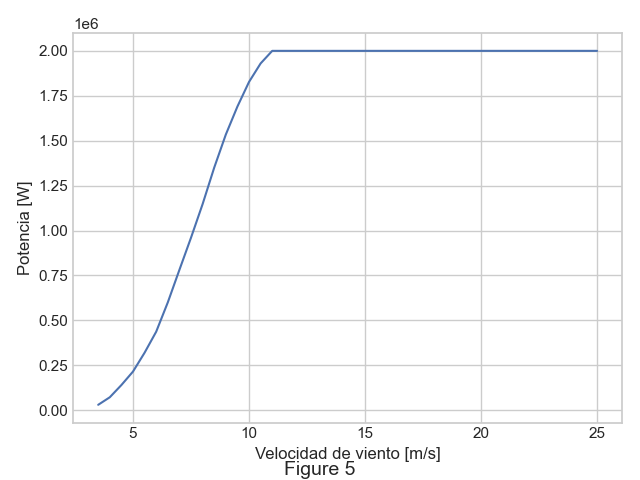

In [15]:
#https://www.thewindpower.net/turbine_es_575_dewind_d8.2.php
#http://windatlas.xyz/turbine/?name=Dewind%20D8.2
plt.figure(plt.gcf().number+2)
plt.plot(df_mf_curve.index,df_mf_curve.pw)
plt.xlabel('Velocidad de viento [m/s]')
plt.ylabel('Potencia [W]')
plt.figtext(0.5, 0.01, 'Figure '+ str(plt.gcf().number), wrap=True, horizontalalignment='center', fontsize=14)
plt.tight_layout()
plt.show()

# Markov

## Step plot 
En el step plot se observan los cambios de estados a lo largo del tiempo.


In [16]:
#convetir matriz de estados a vector de estados (o transiciones)
#este vector debe ser igual a kmeans_labels  cuando no se ha modificado el df
vect_states = myfunc.mat_to_vector(dfclvv)
#primera fecha de registro de datos
first_date= df_wind_dir.index[0]
last_date =  df_wind_dir.index[-1]
wdg_stateplot_datepicker =widgets.DatePicker(description='(mm/dd/YYYY:', disabled=False, start=first_date )
wdg_stateplot_datepicker.value=first_date
wdg_stateplot_actbutton = widgets.Button(description='Actualizar')
display(wdg_stateplot_datepicker)
display(wdg_stateplot_actbutton)

def on_button_stateplot_clicked(b):
    """
    Crea un stepplot de acuerdo a la fecha seleccionada
    :param b:
    """

    mask_month = df_wind_dir.index.month ==wdg_stateplot_datepicker.value.month
    mask_day =  df_wind_dir.index.day ==wdg_stateplot_datepicker.value.day
    data = df_wind_dir.loc[mask_month & mask_day ]
    fig, ax = plt.subplots(figsize=(15,5))

    ax.step(data.index,clusters_wind.kmeans_labels[:len(data)],where='post')
    hours = mdates.MinuteLocator(interval=30)
    h_fmt = mdates.DateFormatter('%H:%M')
    ax.xaxis.set_major_locator(hours)
    ax.xaxis.set_major_formatter(h_fmt)
    plt.xticks(rotation = 90)
    ax.set_xticks(pd.date_range(start=wdg_stateplot_datepicker.value, end=wdg_stateplot_datepicker.value+pd.to_timedelta('1D'),
                                freq='30min'))
    plt.suptitle(str(wdg_stateplot_datepicker.value.strftime('%Y-%m-%d')))
    plt.tight_layout()
    plt.xlabel('Hora del día')
    plt.ylabel('Estado')
    plt.show()

wdg_stateplot_actbutton.on_click(on_button_stateplot_clicked)


DatePicker(value=Timestamp('2005-01-01 00:10:00'), description='(mm/dd/YYYY:')

Button(description='Actualizar', style=ButtonStyle())

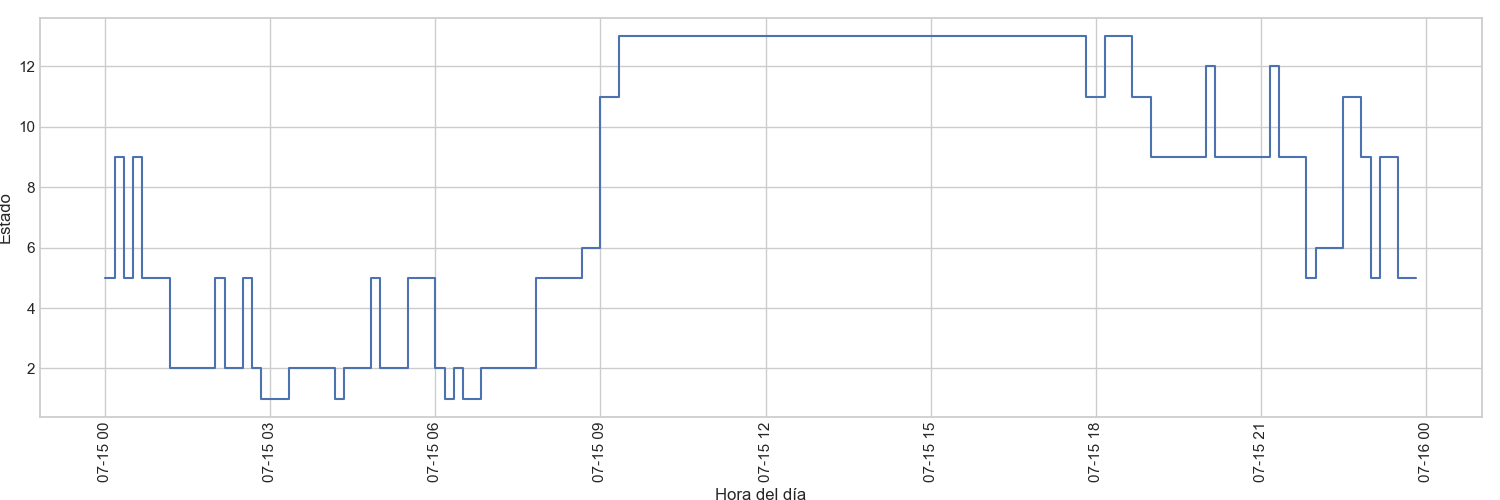

In [17]:
# un solo dia
mask_month = df_wind_dir.index.month ==wdg_stateplot_datepicker.value.month
mask_day =  df_wind_dir.index.day ==wdg_stateplot_datepicker.value.day
mask_month = df_wind_dir.index.month ==pd.to_datetime('2005/07/15').month
mask_day =  df_wind_dir.index.day ==pd.to_datetime('2005/07/15').day
data = df_wind_dir_cl.loc[mask_month & mask_day  ]
lcluster =df_wind_dir_cl.loc[mask_month & mask_day ].cluster.apply(lambda x:int(x[1:]))

fig, ax = plt.subplots(figsize=(15,5))

#ax.step(data.index,clusters_wind.kmeans_labels[:len(data)],where='post')
ax.step(data.index,lcluster,where='post')

# hours = mdates.MinuteLocator(interval=30)
# h_fmt = mdates.DateFormatter('%H:%M')
# ax.xaxis.set_major_locator(hours)
# ax.xaxis.set_major_formatter(h_fmt)
plt.xticks(rotation = 90)
#ax.set_xticks(pd.date_range(start=pd.to_datetime('2005/06/01'), end=pd.to_datetime('2005/06/01')+pd.to_timedelta('1M'),
# freq='30min'))
#plt.suptitle(str(wdg_stateplot_datepicker.value.strftime('%Y-%m-%d')))
plt.tight_layout()
plt.xlabel('Hora del día')
plt.ylabel('Estado')
plt.show()


## Matriz de transición de probabilidades

In [18]:
dfclvv = myfunc.create_clustered_data(df_wind_dir,clusters_wind.kmeans_labels)


In [19]:
o = [13,  5, 11, 0,  4, 9,  8,  6, 10, 12,  2,  1, 14,  7,  3]
df_wind_dir.vwind[clusters_wind.kmeans_labels==13]

timeStamp
2005-01-01 00:30:00    0.893
2005-01-01 00:40:00    1.016
2005-01-01 01:20:00    0.333
2005-01-01 01:30:00    0.032
2005-01-01 01:40:00    0.651
                       ...  
2005-12-31 20:10:00    1.270
2005-12-31 20:20:00    1.235
2005-12-31 23:30:00    1.072
2005-12-31 23:40:00    1.254
2005-12-31 23:50:00    0.531
Name: vwind, Length: 12748, dtype: float64

In [20]:
df_wind_dir.vwind


timeStamp
2005-01-01 00:10:00    1.898
2005-01-01 00:20:00    1.759
2005-01-01 00:30:00    0.893
2005-01-01 00:40:00    1.016
2005-01-01 00:50:00    1.092
                       ...  
2005-12-31 23:10:00    1.535
2005-12-31 23:20:00    2.085
2005-12-31 23:30:00    1.072
2005-12-31 23:40:00    1.254
2005-12-31 23:50:00    0.531
Name: vwind, Length: 52559, dtype: float64

In [21]:
dfclvv.sort_index()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,C15
2005-01-01 00:10:00,NaN,1.898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:20:00,NaN,1.759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:30:00,0.893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:40:00,1.016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-01 00:50:00,NaN,NaN,1.092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-12-31 23:10:00,NaN,1.535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-31 23:20:00,NaN,NaN,NaN,2.085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-31 23:30:00,1.072,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-12-31 23:40:00,1.254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


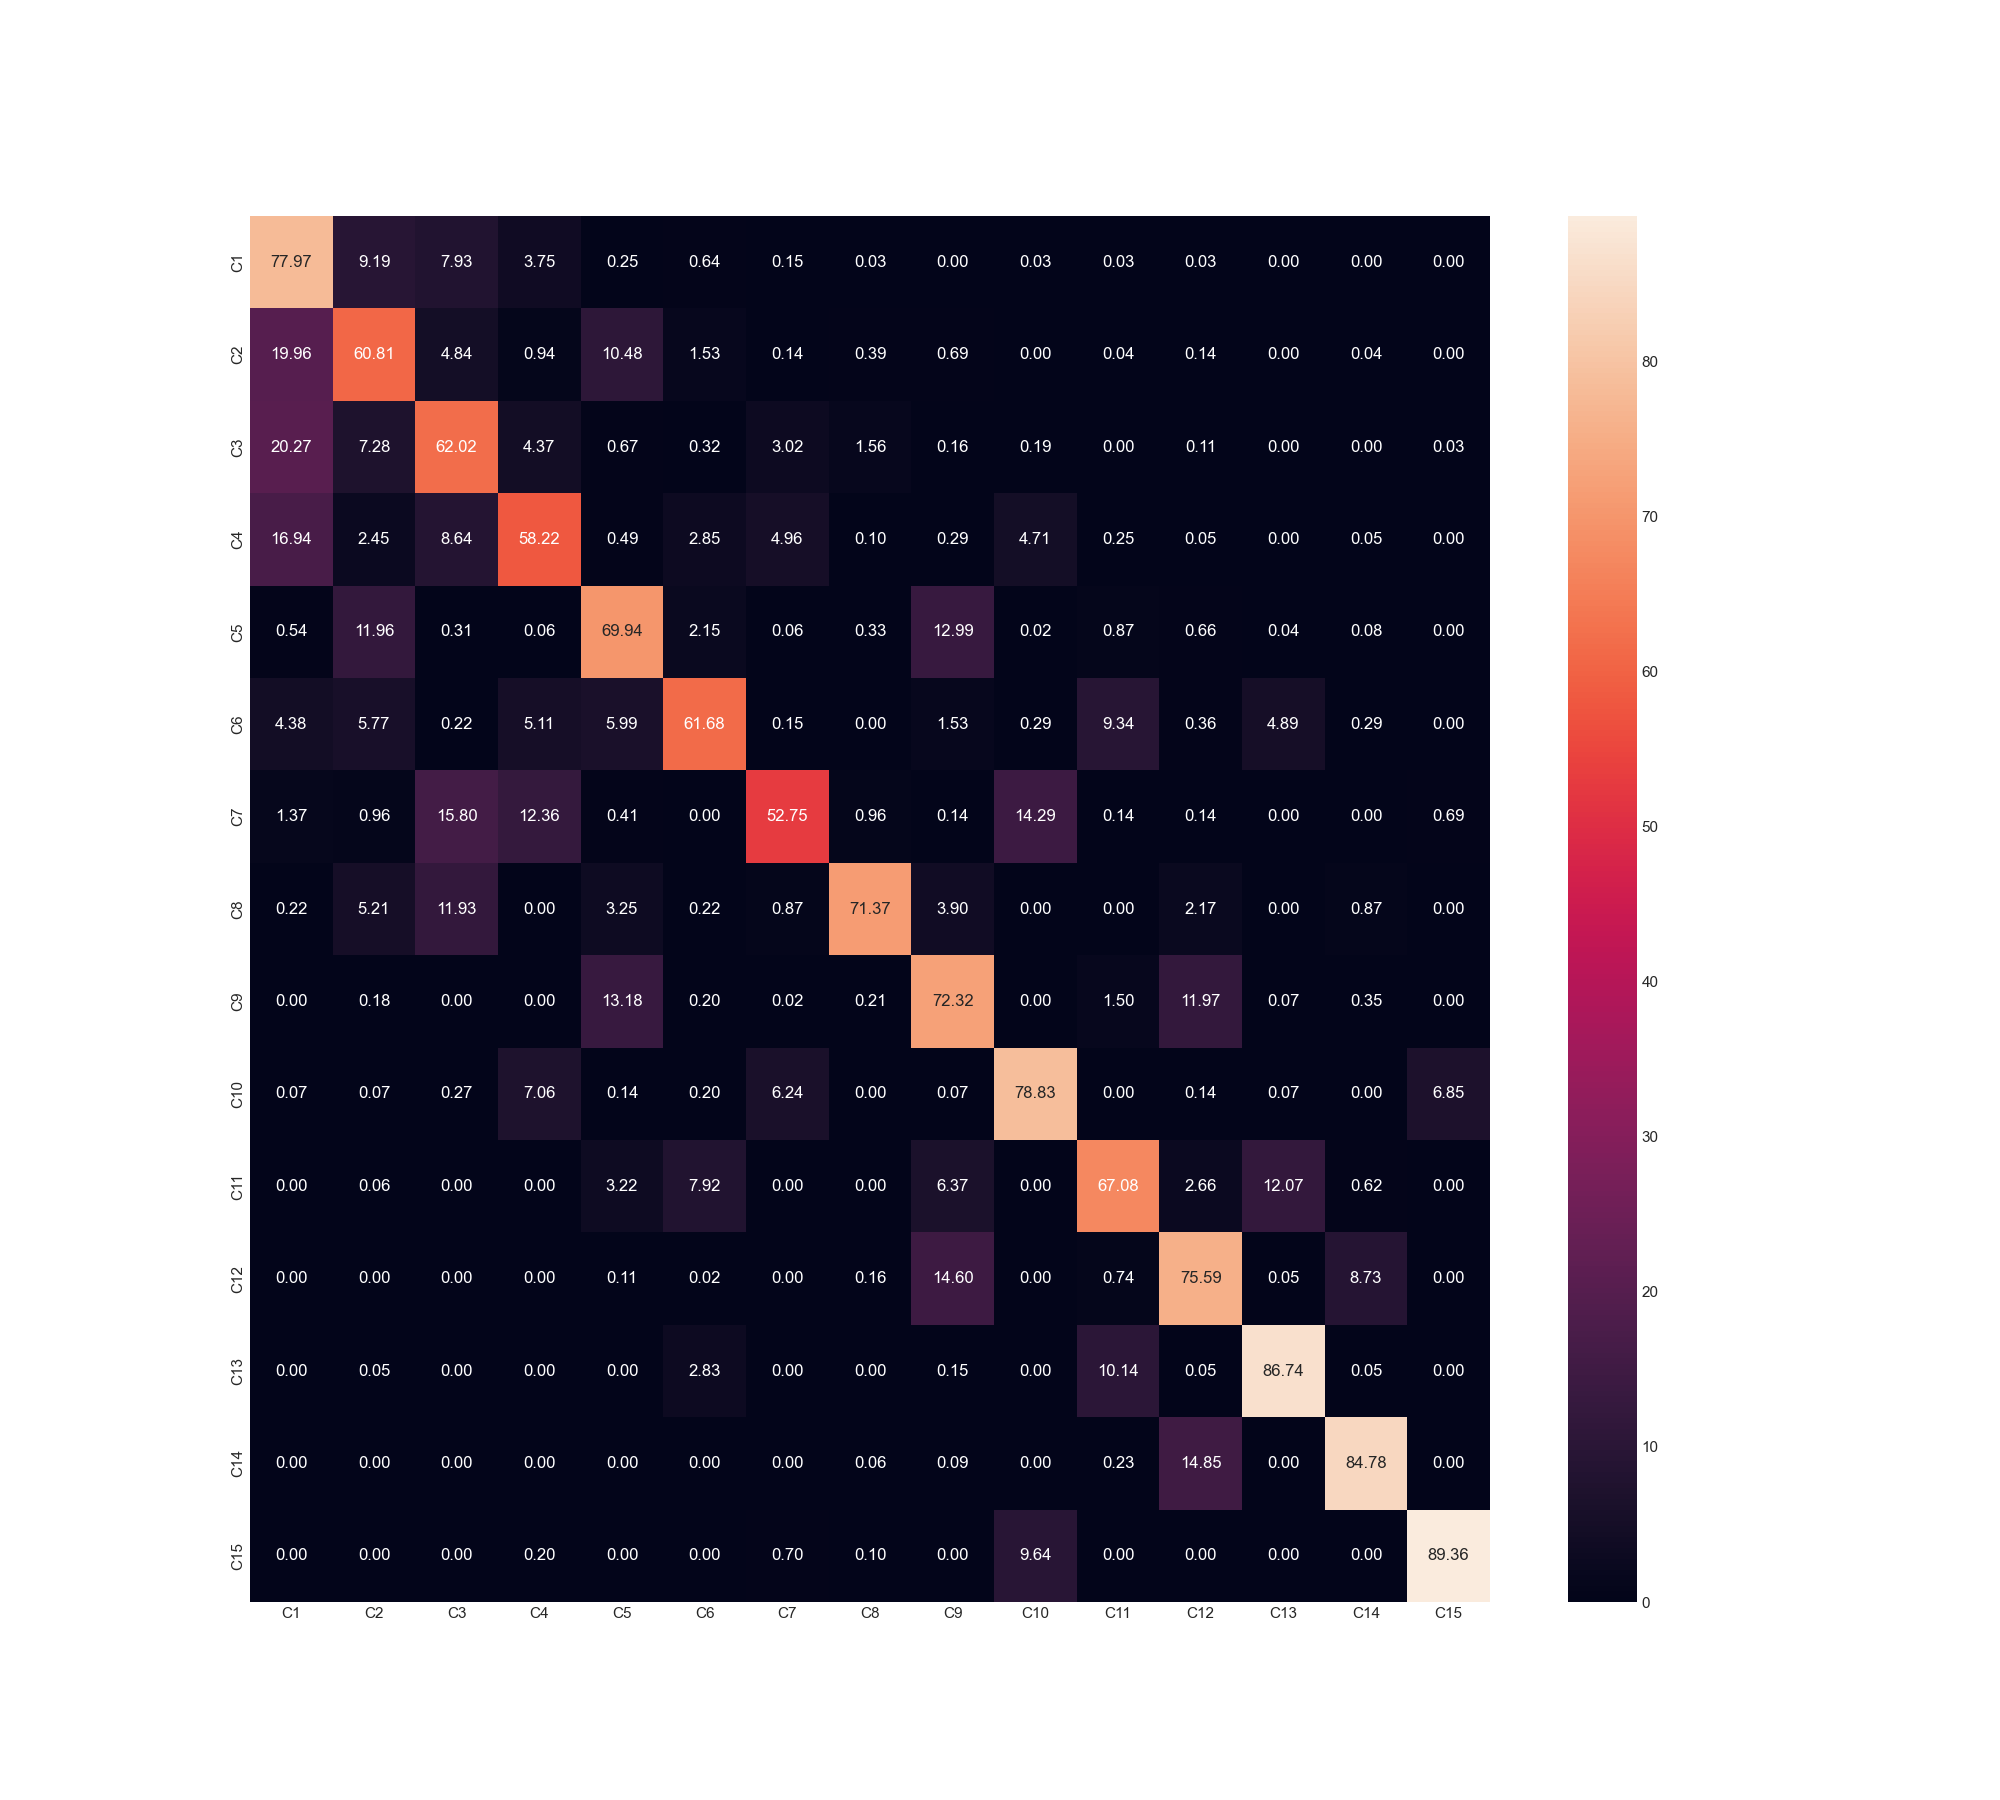

In [22]:
mat_trans_prob= myfunc.trans_matrix_from_df(dfclvv.sort_index(),mat_mode='prob')
#SOLO FUNCIONA PARA FILAS PERO NO PARA COLUMNAS
plt.figure(figsize=(20,18))

ht =sns.heatmap(mat_trans_prob, annot=True,fmt='.2f')
figure = ht.get_figure()
plt.show()

## Cadena de Markov para valores de prob. mayor a 10%


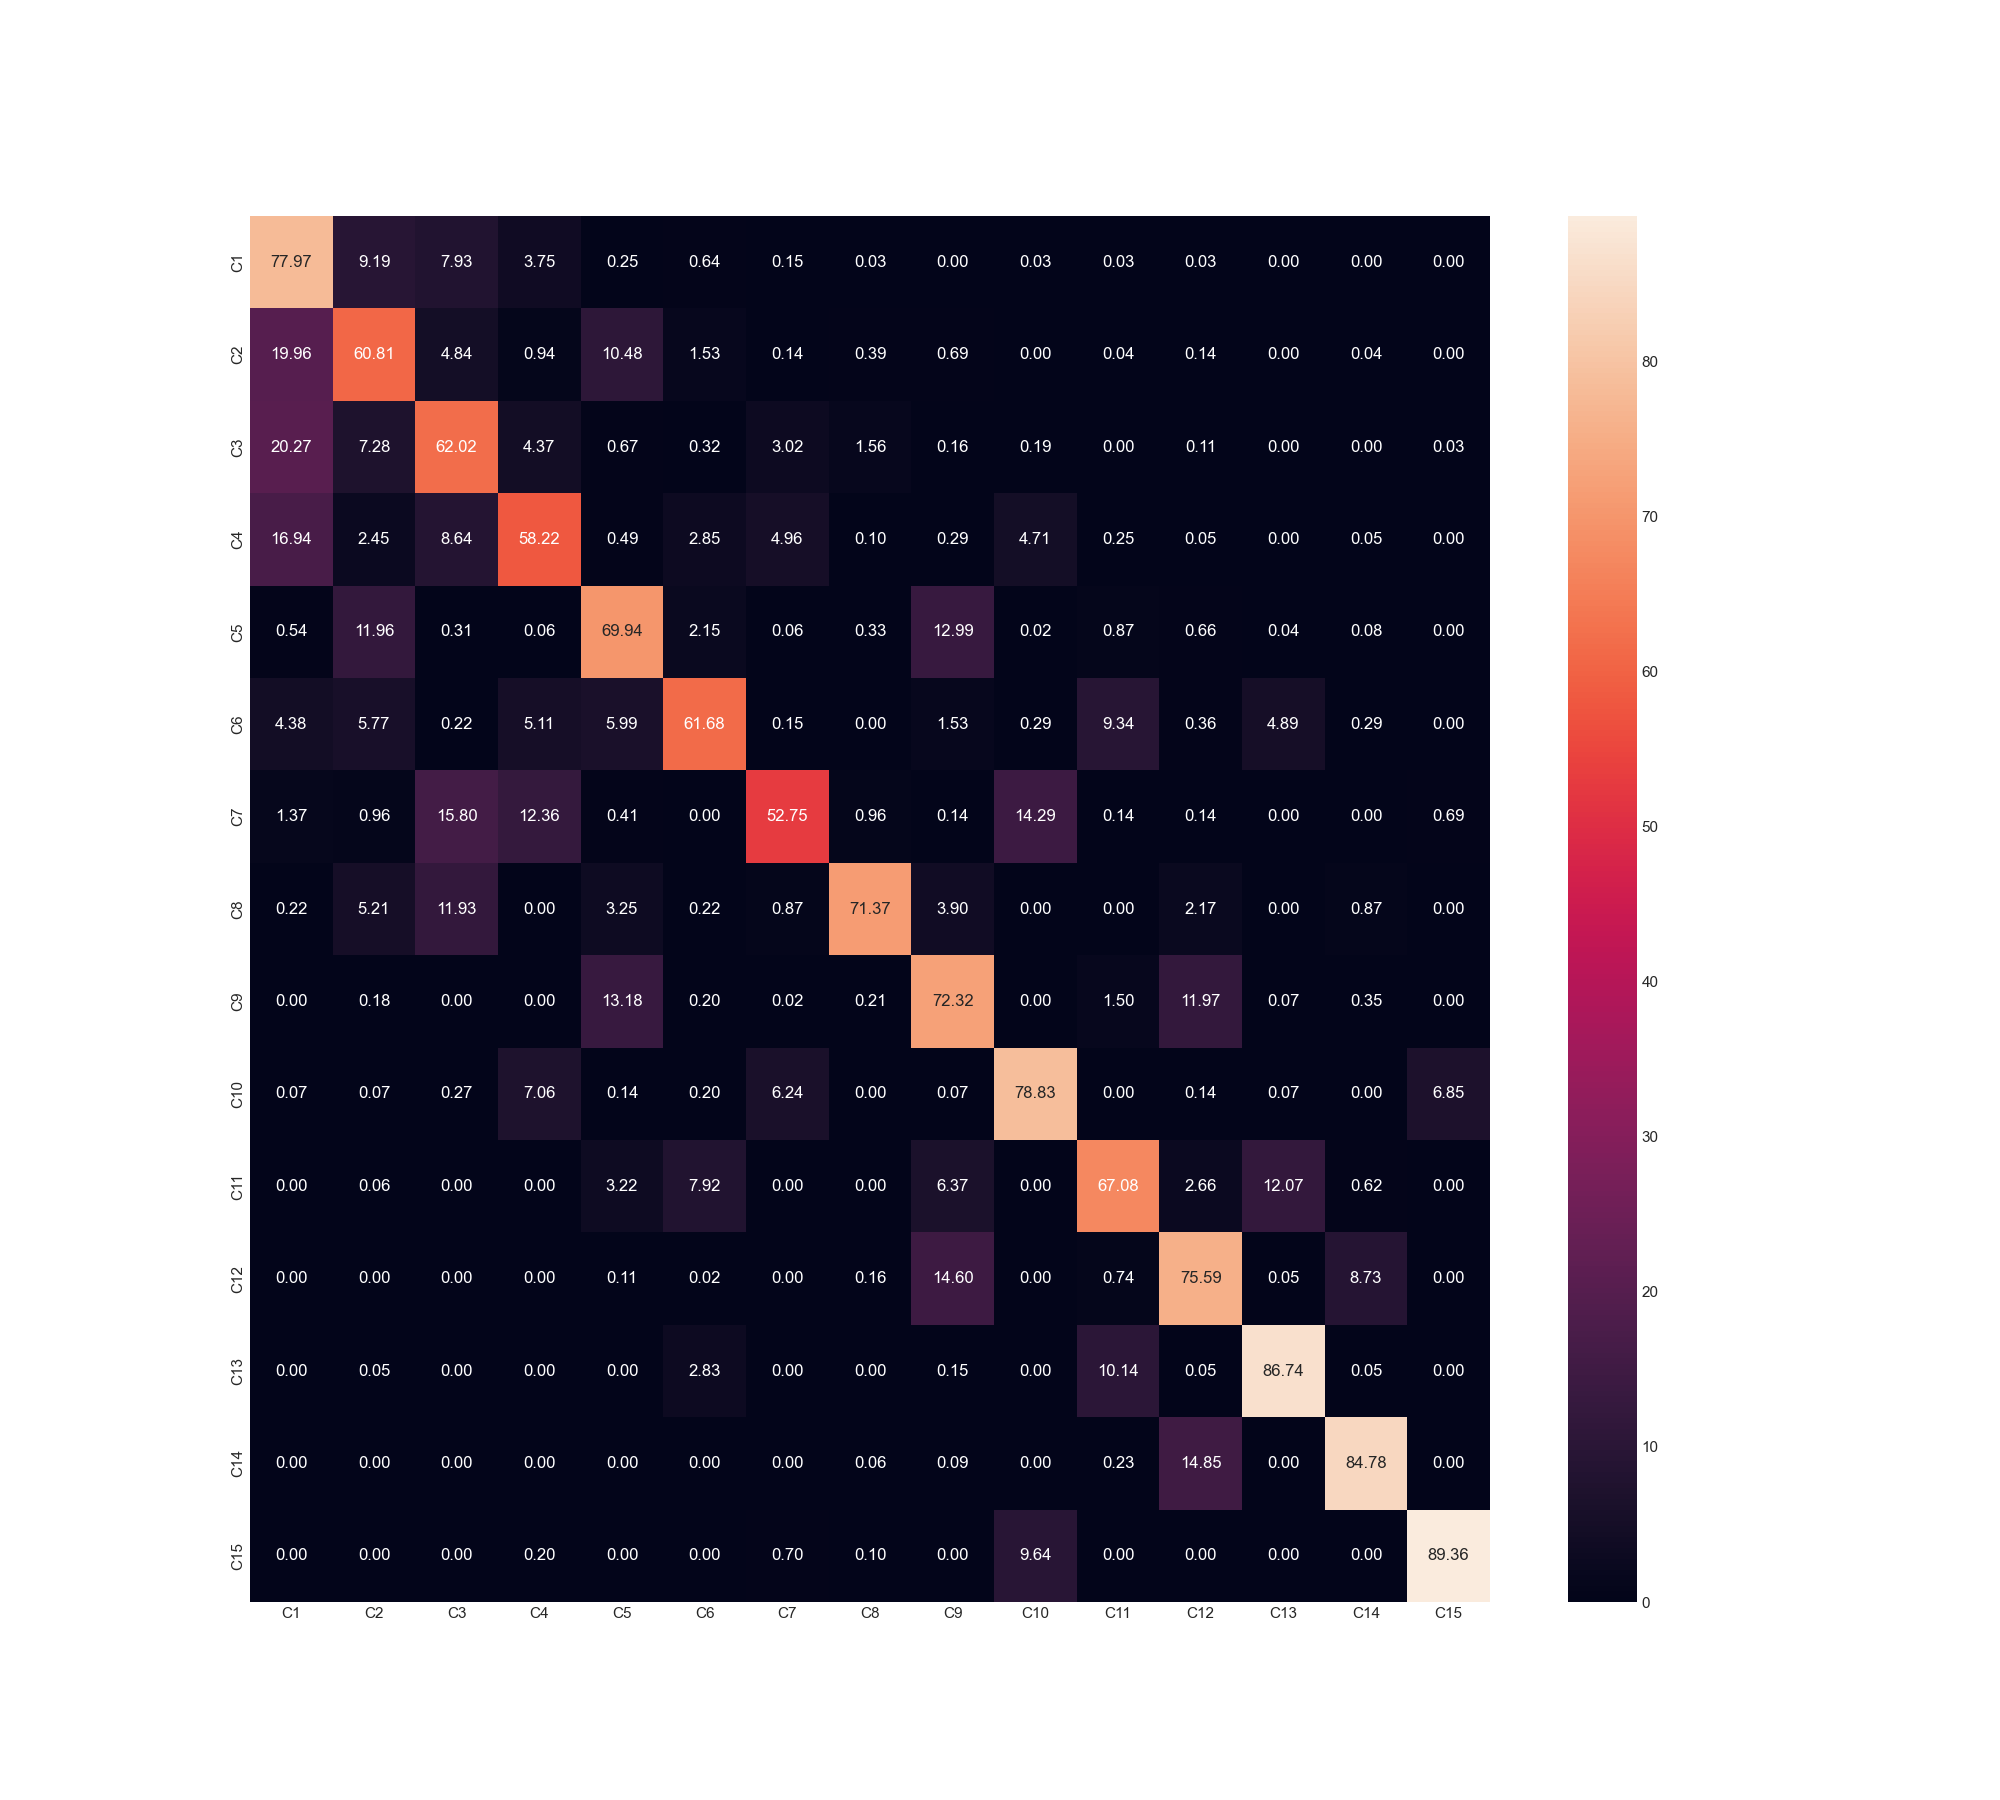

In [23]:
#eliminar valores menores a 10%
matprob10p = mat_trans_prob.mask(mat_trans_prob<10)
#conviertiendo nan a cero
matprob10p.fillna(0,inplace=True)
matprob10p = np.round(matprob10p,4)
plt.figure(figsize=(20,18))

ht10 =sns.heatmap(mat_trans_prob, annot=True,fmt='.2f')
figure = ht10.get_figure()
plt.show()





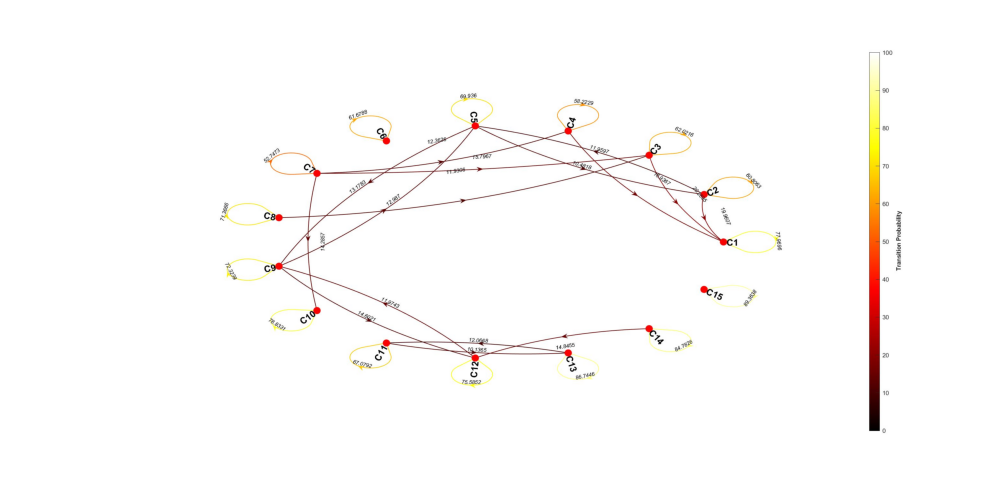

In [24]:
# crear diagrama de cadena de Markov
myfunc.create_mc_plot(21,matprob10p.copy(), as_pct=True, replace_zero_to_nan=True, layout='circle');

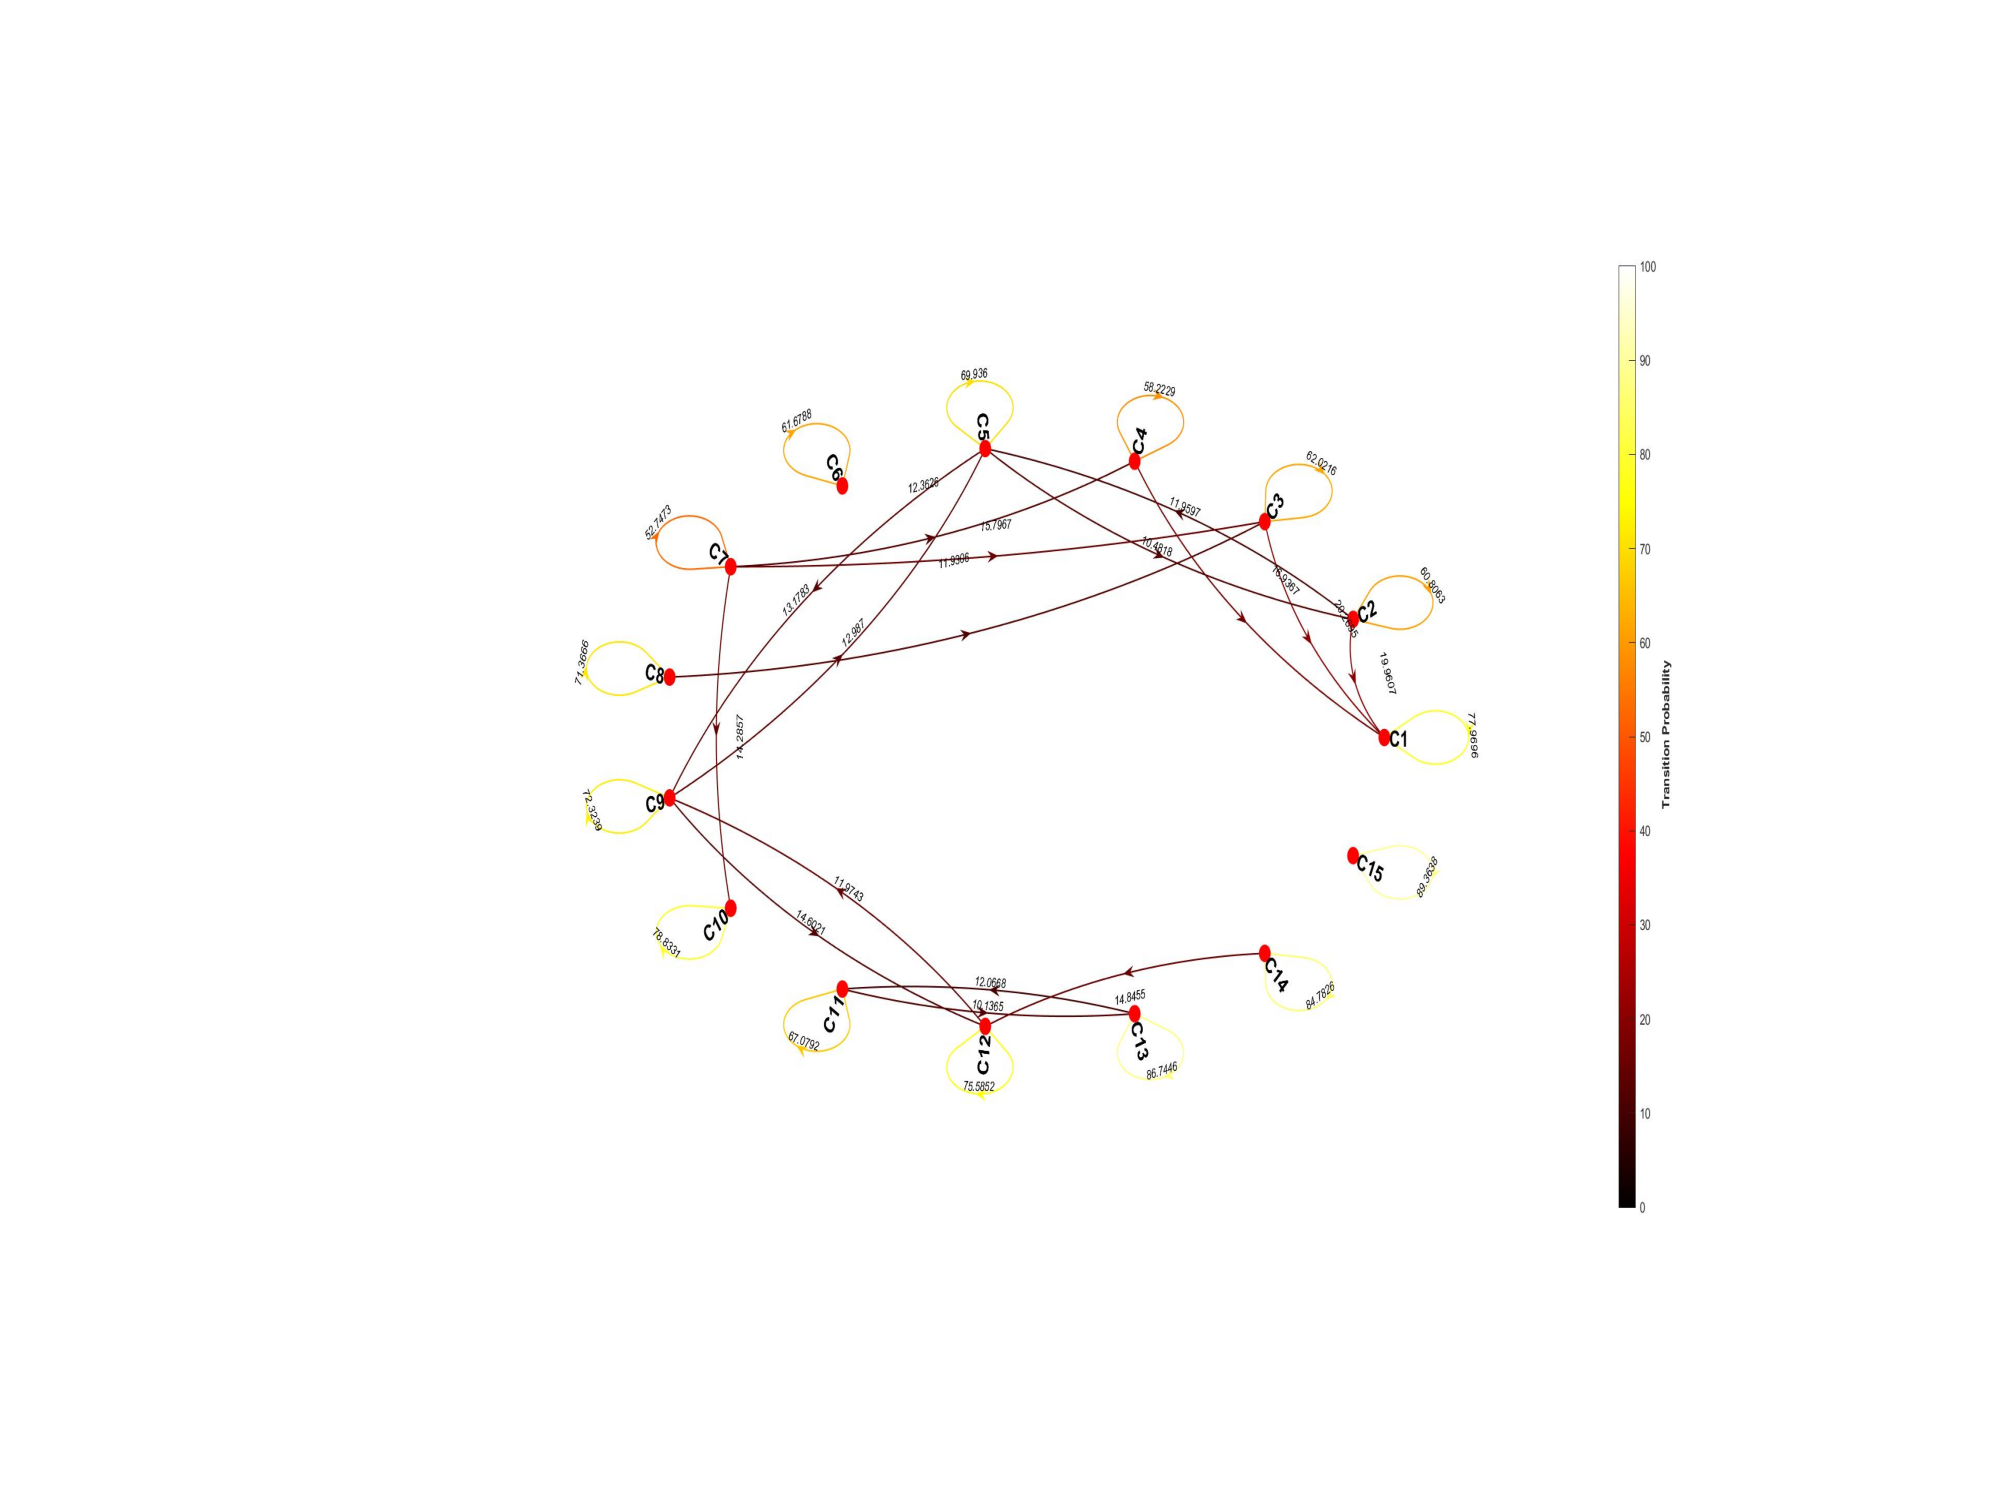

In [25]:
img = image.imread('graph_mc.jpg')
plt.figure(figsize=(20,15))
plt.imshow(img,aspect='auto')
plt.grid(False)
plt.axis('off')
plt.show()

In [26]:
# import subprocess
# matlab_path= r"C:\Program Files\MATLAB\R2021b\bin\matlab.exe"
# matlab_script_path = r"'C:\Users\mungu\Documents\GitHub\aero\m_script_markov.m'"
# #matlab_cmd = matlab_path + ' -noFigureWindows -nodesktop  -r run(' + matlab_script_path+');quit'
# #matlab_cmd = matlab_path + ' -batch ' + matlab_script_path
# matlab_cmd = matlab_path + ' -batch run(' + matlab_script_path+')'
# result = subprocess.run(matlab_cmd, stderr=subprocess.STDOUT)
# if result.stderr:
#     raise subprocess.CalledProcessError(
#         returncode = result.returncode,
#         cmd = result.args,
#         stderr = result.stderr
#     )


## Matriz de transición de probabilidades con clusters agrupados

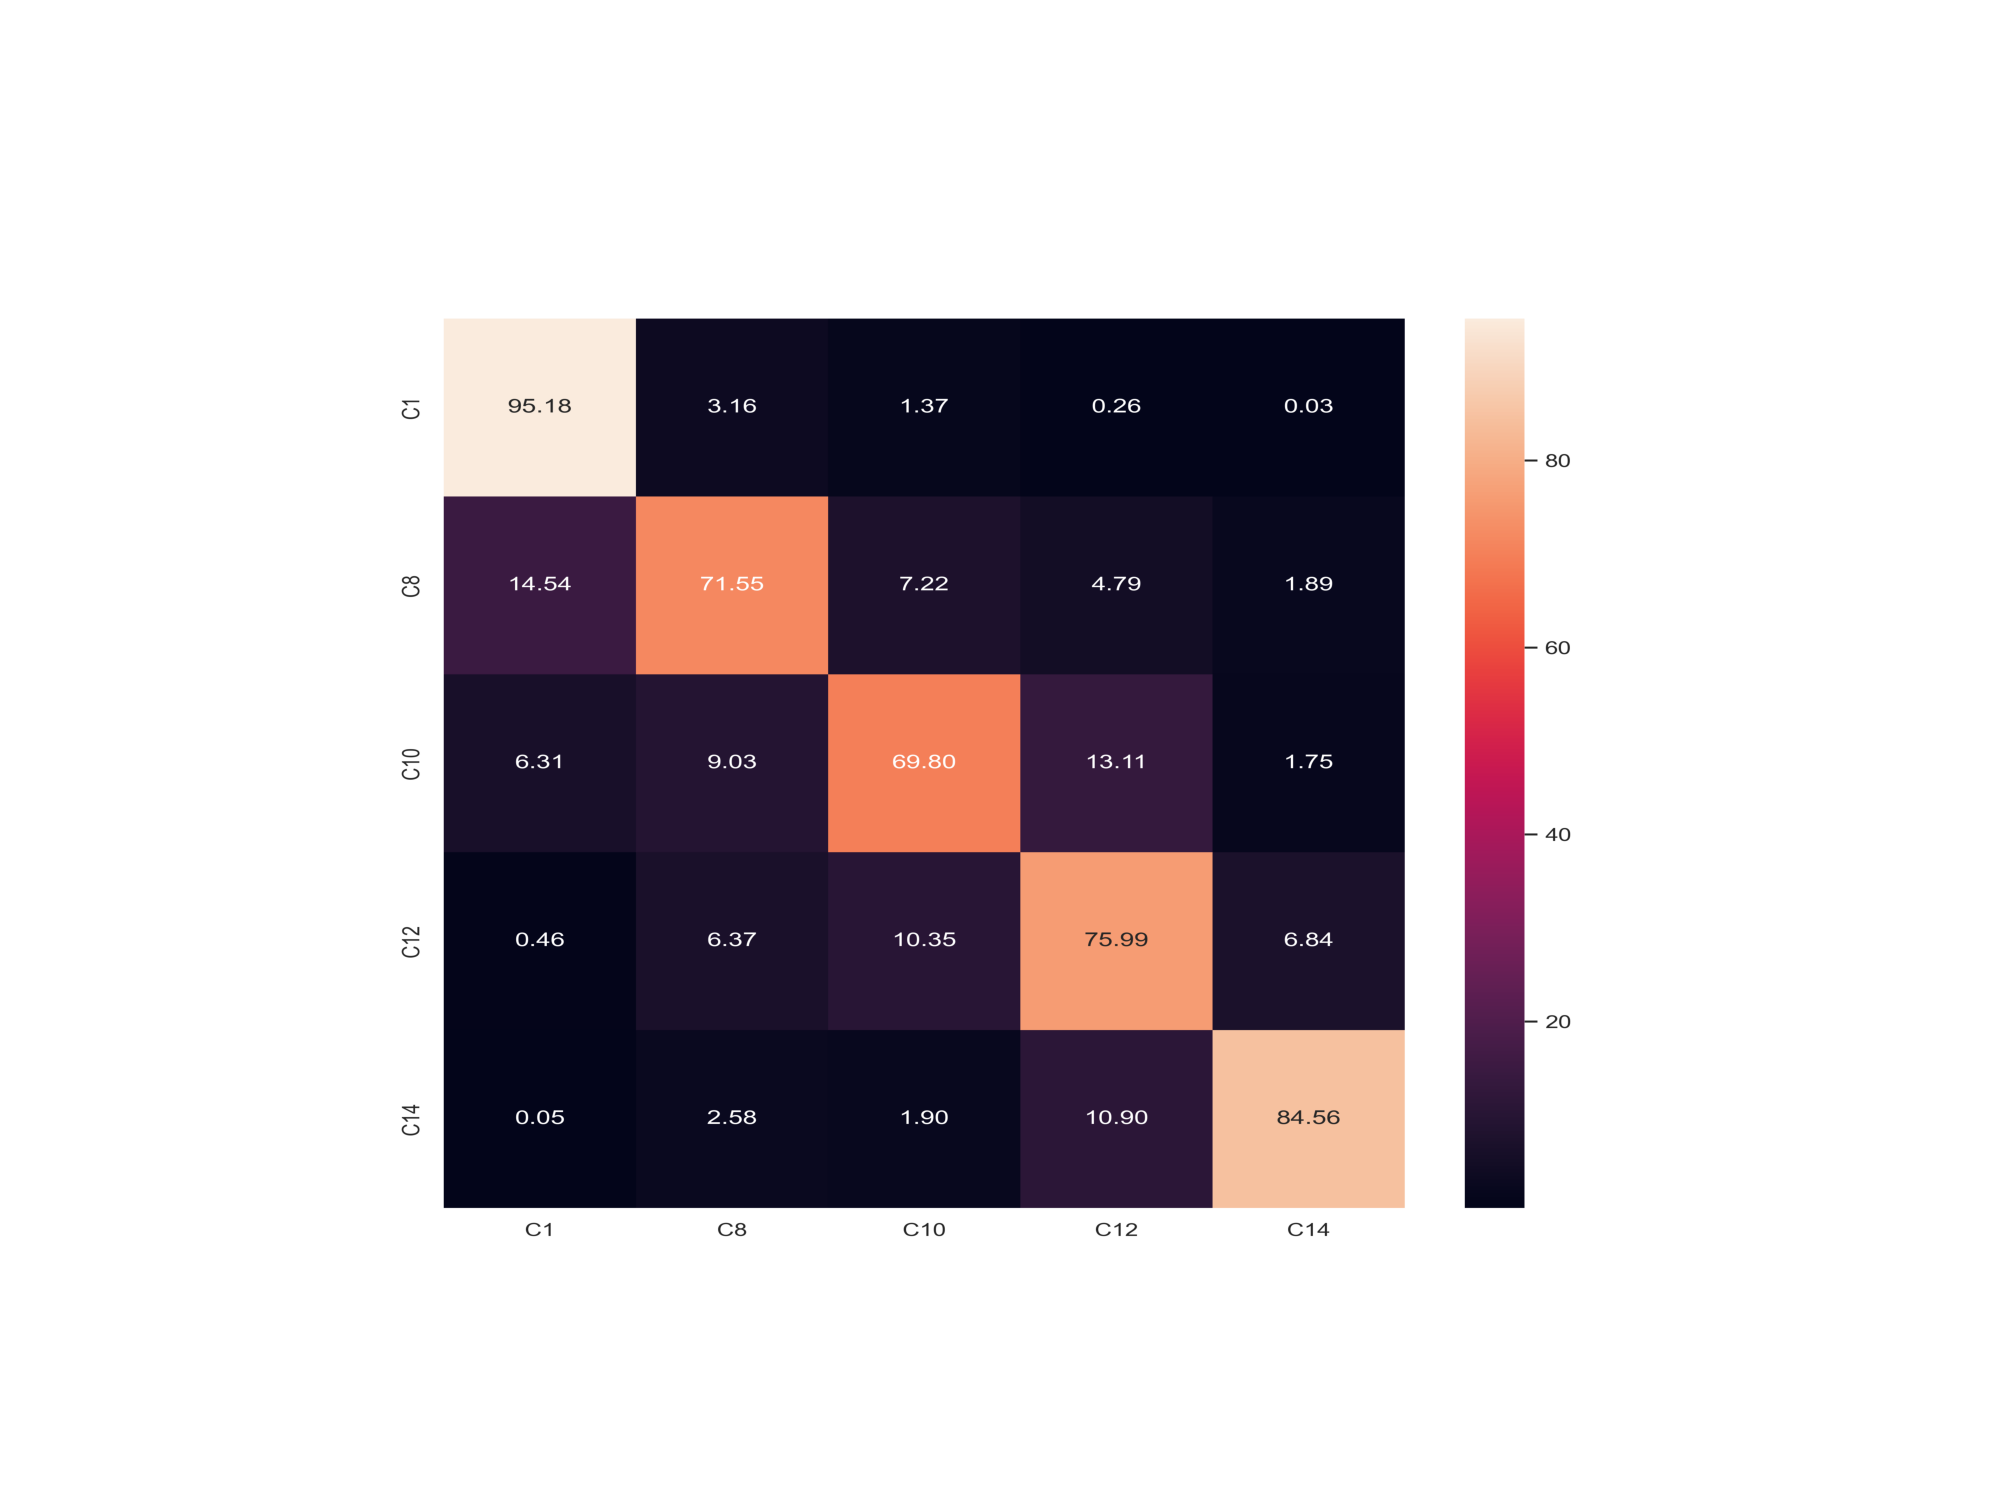

In [27]:
img = image.imread('ht_prob_joined_bk.png')
plt.figure(figsize=(20,15))
plt.imshow(img,aspect='auto')
plt.grid(False)
plt.axis('off')
plt.show()
